# Prospect Theory

## Certain-vs-Gamble Task ([Tversky & Kahneman, 1992](https://doi.org/10.1007/BF00122574))

On each trial, an agent chooses between a **certain** amount and a two-outcome **gamble** (outcomes $o_1, o_2$ occurring with probabilities $p_1, p_2 = 1-p_1$; gambles may mix gains and losses). Subjective values follow prospect theory's power value function, with separate curvature for gains/losses ($\alpha,\beta$) and a loss-aversion multiplier ($\lambda$), combined with a one-parameter probability-weighting function ($\gamma$). Choices follow a logistic rule with temperature $\mu$.

$$
\textbf{Value function:}\quad
v(x) =
\begin{cases}
x^{\alpha}, & x \ge 0\\[4pt]
-\lambda \, (-x)^{\beta}, & x < 0
\end{cases}
\tag{1}
$$

$$
\textbf{Probability weighting:}\quad
w(p) = \dfrac{p^{\gamma}}{\left(p^{\gamma} + (1-p)^{\gamma}\right)^{1/\gamma}}
\tag{2}
$$

$$
\textbf{Gamble value:}\quad
V_g = w(p_1)\, v(o_1) + w(p_2)\, v(o_2)
\tag{3}
$$

$$
\textbf{Certain value:}\quad
V_c = v(\text{certain})
\tag{4}
$$

$$
\textbf{Choice rule:}\quad
P(\text{choose gamble}) = \operatorname{expit}\big(\mu\,(V_g - V_c)\big)
\tag{5}
$$

Free parameters: `pt_alpha` (gain curvature), `pt_beta` (loss curvature), `pt_lambda` (loss aversion), `pt_gamma` (probability-weighting curvature), `pt_mu` (choice temperature).


In [1]:
import numpy as np
from pyem import EMModel
from pyem.models.pt import pt_model
from params import build_params

# ModelSpec bundles this model's identity, description, and sim/fit entry points
print(f"Model ID   : {pt_model.id}")
print(f"Description: {pt_model.desc}")
print(f"Spec       : {pt_model.spec}")

Model ID   : pt
Description: Prospect Theory (Tversky & Kahneman, 1992) model of choices
between a certain amount and a two-outcome gamble. A power value function
with separate gain/loss curvature (alpha/beta) and a loss-aversion
multiplier (lambda) is combined with a one-parameter probability weighting
function (gamma); choices follow a logistic rule with temperature mu.
Free parameters: alpha, beta, lambda, gamma, mu.
Spec       : {'prospect_theory': {'value': ['alpha', 'beta', 'lambda'], 'weighting': ['gamma'], 'choice': ['mu']}}


In [2]:
# simulate computer agents completing the certain-vs-gamble task
nsubjects, ntrials = 100, 200

# generate "true" parameters using the shared parameter registry (examples/params.py)
names = ["pt_alpha", "pt_beta", "pt_lambda", "pt_gamma", "pt_mu"]
param_names, param_xform, true_params = build_params(names, nsubjects, rng=np.random.default_rng(0))

recover(): this model's data and outfit now reflect the recovery fit; the recovered estimates are also in the returned dict['recovery_model'].


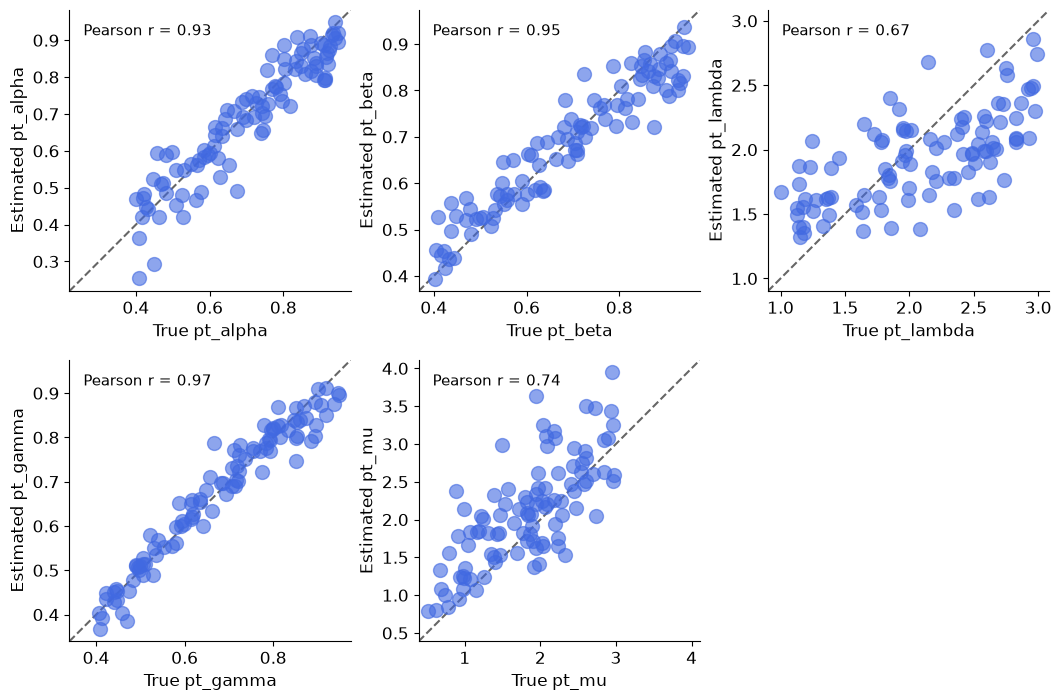

In [3]:
# use EMModel.recover to run simulation, fitting and recovery metrics
model = EMModel(all_data=None, fit_func=pt_model.fit, param_names=param_names,
                param_xform=param_xform, simulate_func=pt_model.sim)

recovery = model.recover(true_params, pr_inputs=["gamble", "probs", "certain", "choice"],
                         ntrials=ntrials, fit_kwargs={"seed": 0, "mstep_maxit": 40, "njobs": 10})

# scatter plot of recovered parameters
fig = model.plot_recovery(recovery, show=False)

The recovery dictionary also contains numerical summaries such as
`recovery['correlation']`, which provides a correlation coefficient for each
parameter.

**References**

Tversky, A., & Kahneman, D. (1992). Advances in prospect theory: Cumulative representation of uncertainty. *Journal of Risk and Uncertainty*, 5(4), 297-323. https://doi.org/10.1007/BF00122574